In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
from src.validator import validador, rules, produccion, expenses_op, general_G

In [2]:
df = pd.read_csv("../dataFrames/data.csv")
df.head()

,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,EMPAQUE,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
0,987664,4711-472,471-472,11.0,1986.0,0,603028,"112214,5",0,0,...,2409090,2499584,4837343,2454337,4837343,4837343,0,4980000,1110,5145586
1,987666,462,462-463,14.0,1996.0,0,1083695,77336,780,2970,...,3193,476400,4820346,"239796,5",4820346,4820346,0,4928292,1255,5288743
2,987667,4771-4751,476 - 477,4.0,1991.0,0,190661,26863,0,0,...,431759,422759,515488,427259,515488,515488,0,548094,16772,701070
3,987668,466,466-469,14.0,1986.0,0,2459238,"1262835,5",0,0,...,1963161,2694017,13114471,2328589,13114471,13114471,0,14487926,62938,14895893
4,987669,473,473,5.0,2004.0,0,1688361,"218895,5",0,0,...,141377,172460,7766200,"156918,5",7766200,7766200,0,8044113,57255,8847340


In [ ]:
df = df[produccion+expenses_op+general_G]

df.info()
# transformar IDOJ1,IDAIO  a un entero

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   VENTA        9984 non-null   object
 1   BRUTA        9984 non-null   object
 2   CONSUI       9984 non-null   object
 3   AGREGA       9984 non-null   object
 4   CTO          9983 non-null   object
 5   GAS          9984 non-null   object
 6   EMPAQUE      9984 non-null   object
 7   HONORA       9984 non-null   object
 8   COMISION     9984 non-null   object
 9   ARRIENDO     9984 non-null   object
 10  SEGURO       9984 non-null   object
 11  ASEO         9984 non-null   object
 12  ENERGIA      9984 non-null   object
 13  COMUNICA     9984 non-null   object
 14  PUBLICO      9984 non-null   object
 15  FLETES       9984 non-null   object
 16  PUBLICI      9984 non-null   object
 17  ADECUA       9984 non-null   object
 18  REGALA       9984 non-null   object
 19  OUTSOURCING  9984 non-null 

In [4]:
for col in df.columns:
    df[col] = df[col].apply(lambda x: str(x).replace(',', '').replace(' ', '')).astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9984 entries, 0 to 9983
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   VENTA        9984 non-null   float64
 1   BRUTA        9984 non-null   float64
 2   CONSUI       9984 non-null   float64
 3   AGREGA       9984 non-null   float64
 4   CTO          9983 non-null   float64
 5   GAS          9984 non-null   float64
 6   EMPAQUE      9984 non-null   float64
 7   HONORA       9984 non-null   float64
 8   COMISION     9984 non-null   float64
 9   ARRIENDO     9984 non-null   float64
 10  SEGURO       9984 non-null   float64
 11  ASEO         9984 non-null   float64
 12  ENERGIA      9984 non-null   float64
 13  COMUNICA     9984 non-null   float64
 14  PUBLICO      9984 non-null   float64
 15  FLETES       9984 non-null   float64
 16  PUBLICI      9984 non-null   float64
 17  ADECUA       9984 non-null   float64
 18  REGALA       9984 non-null   float64
 19  OUTSOU

In [5]:
# evaluacion de el dataset

resultado = validador(df, rules)

print(resultado)

                   regla  cantidad_invalidos  porcentaje_invalidos
0                  nulos                   1                  0.01
1       venta_produccion                  63                  0.63
2     produccion_consumo                4183                 41.90
3         valor_agregado                  45                  0.45
4                 costos                   6                  0.06
5             eficiencia                  36                  0.36
6    margen_val_agregado                1872                 18.75
7    consistencia_gastos                 136                  1.36
8      proporcion_ventas                 142                  1.42
9   peso_relativo_gastos                 275                  2.75
10    rentabilidad_bruta                  36                  0.36


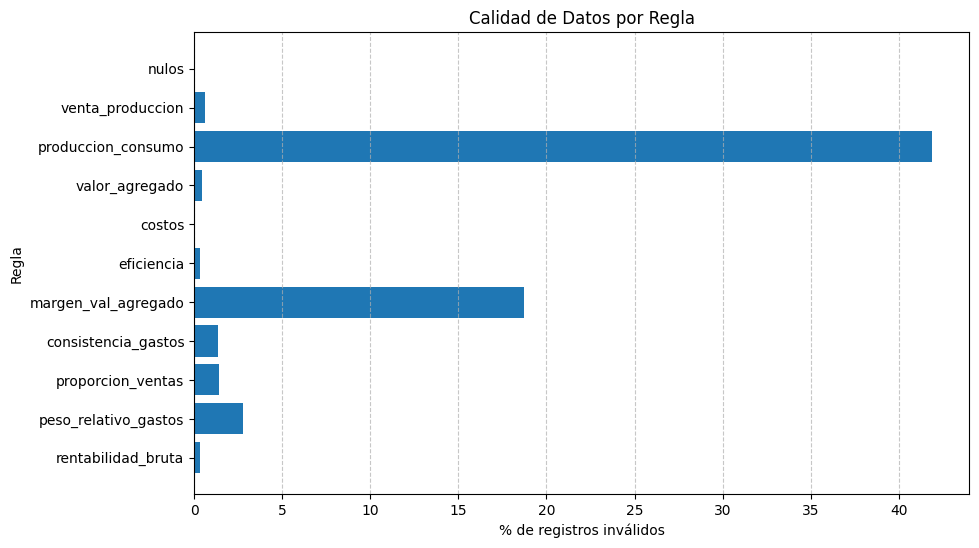

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(resultado['regla'], resultado['porcentaje_invalidos'])
plt.xlabel('% de registros inválidos')
plt.ylabel('Regla')
plt.title('Calidad de Datos por Regla')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
